In [3]:
#importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

In [4]:
#importing the file

df = pd.read_excel("/content/master_final.xlsx")

In [5]:
#monthly revenue

monthly_revenue = df.groupby(pd.Grouper(key = "order_purchase_timestamp", freq = "ME")).agg(revenue = ("price", "sum"))

In [6]:
monthly_revenue.reset_index()

,order_purchase_timestamp,revenue
0,2016-09-30,267.36
1,2016-10-31,49507.66
2,2016-11-30,0.00
3,2016-12-31,10.90
4,2017-01-31,120312.87
5,2017-02-28,247303.02
6,2017-03-31,374344.30
7,2017-04-30,359927.23
8,2017-05-31,506071.14
9,2017-06-30,433038.60


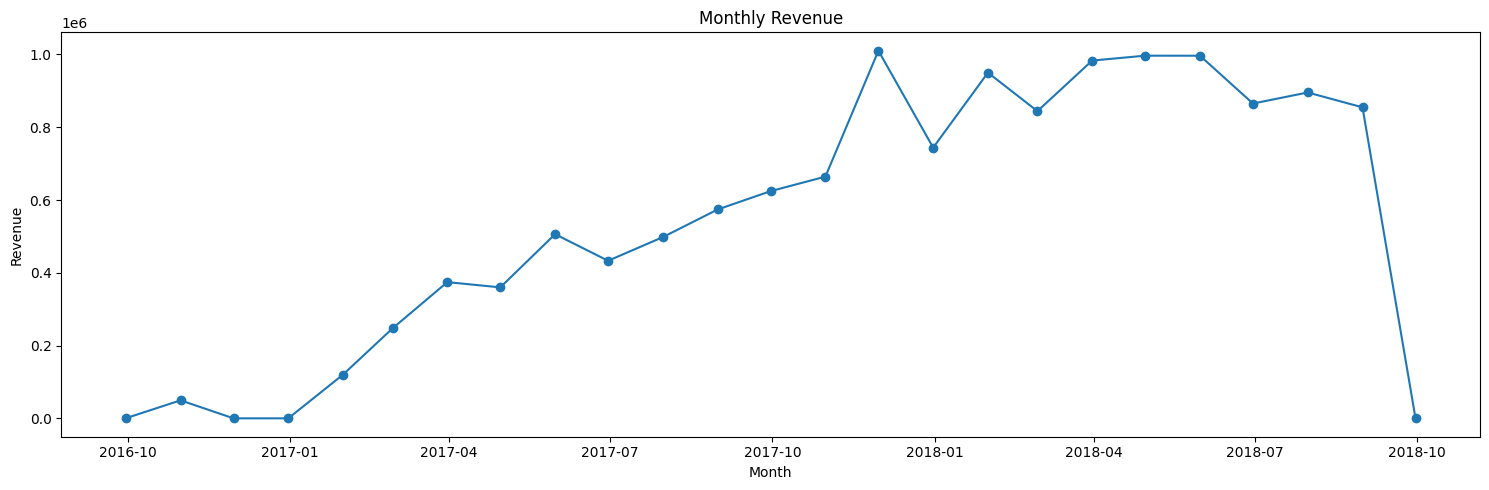

In [7]:
#lets plot it

plt.figure(figsize = (15, 5))

plt.plot(monthly_revenue.index, monthly_revenue.revenue, marker = "o")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue")
plt.tight_layout()
plt.show()

In [8]:
## Time Series Observation

#The monthly revenue series exhibits a clear upward trend from late 2016 through mid-2018, indicating sustained business growth.

#Although monthly revenue fluctuates, there is insufficient historical data to confidently identify a recurring seasonal pattern.

#A noticeable spike in revenue during late 2017 may reflect promotional events or holiday demand and should be investigated further.

#The final observation shows an abrupt decline in revenue, which is likely caused by an incomplete reporting month rather than a genuine decrease in business performance. This observation should be excluded before building forecasting models.

In [9]:
#removing last row of the data as it is not complete

monthly_revenue = monthly_revenue.iloc[:-1]


In [10]:
#moving average forecast

monthly_revenue["MA3"] = (monthly_revenue["revenue"].rolling(window = 3, min_periods = 1).mean())

In [11]:
monthly_revenue["MA6"] = (monthly_revenue["revenue"].rolling(window = 6).mean())
monthly_revenue["MA12"] = (monthly_revenue["revenue"].rolling(window = 12).mean())

In [12]:
monthly_revenue

,revenue,MA3,MA6,MA12
order_purchase_timestamp,,,,
2016-09-30,267.36,267.360000,NaN,NaN
2016-10-31,49507.66,24887.510000,NaN,NaN
2016-11-30,0.00,16591.673333,NaN,NaN
2016-12-31,10.90,16506.186667,NaN,NaN
2017-01-31,120312.87,40107.923333,NaN,NaN
2017-02-28,247303.02,122542.263333,69566.968333,NaN
2017-03-31,374344.30,247320.063333,131913.125000,NaN
2017-04-30,359927.23,327191.516667,183649.720000,NaN
2017-05-31,506071.14,413447.556667,267994.910000,NaN


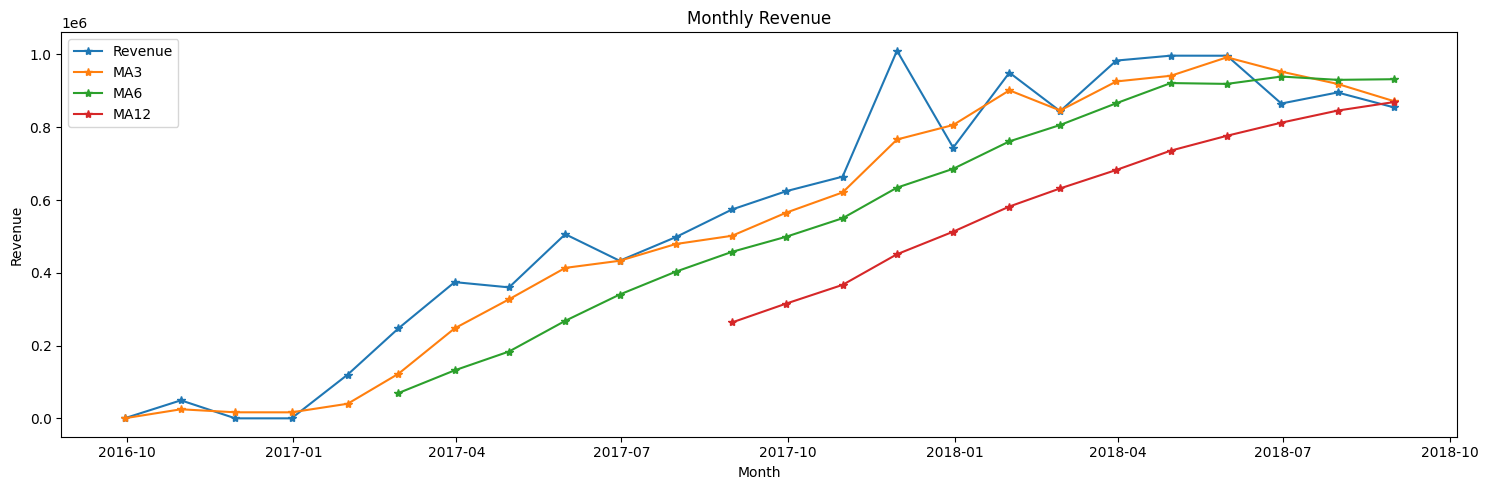

In [13]:
#now plotting revenue, MA3, MA6, MA12

plt.figure(figsize = (15, 5))

plt.plot(monthly_revenue.index, monthly_revenue.revenue, label = "Revenue", marker = "*")
plt.plot(monthly_revenue.index, monthly_revenue.MA3, label = "MA3", marker = "*")
plt.plot(monthly_revenue.index, monthly_revenue.MA6, label = "MA6", marker = "*")
plt.plot(monthly_revenue.index, monthly_revenue.MA12, label = "MA12", marker = "*")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue")
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
#forecasting error practice

forecast_example = pd.DataFrame({
    "Actual":   [100, 120, 140, 160, 180],
    "Forecast": [95, 125, 135, 170, 175]
})

In [15]:
forecast_example["Error"] = forecast_example["Actual"] - forecast_example["Forecast"]

In [16]:
forecast_example["Absolute_Error"] = forecast_example["Error"].abs()

In [17]:
forecast_example["Sqaured_Error"] = forecast_example["Error"] ** 2

In [18]:
forecast_example["Percentage_Error"] = round((forecast_example["Error"]/forecast_example["Actual"] * 100).abs(),2)

In [19]:
MAE = forecast_example["Absolute_Error"].mean()

In [20]:
MSE = forecast_example["Sqaured_Error"].mean()

In [21]:
RMSE = round(np.sqrt(MSE),2)

In [22]:
mean_absolute_percentage_error = forecast_example["Percentage_Error"].mean()

In [23]:
mean_absolute_percentage_error

np.float64(4.354000000000001)

#Simple Exponential Smoothening

In [24]:
model = SimpleExpSmoothing(monthly_revenue["revenue"]).fit(optimized = True)

In [25]:
forecast = model.forecast(3)

In [26]:
print(forecast)

2018-09-30    863908.28886
2018-10-31    863908.28886
2018-11-30    863908.28886
Freq: ME, dtype: float64


#Holt's Linear Trend Model

In [27]:
from statsmodels.tsa.holtwinters import Holt

In [28]:
holt_model = Holt(monthly_revenue["revenue"]).fit(optimized = True)

In [29]:
holt_forecast = holt_model.forecast(6)

In [30]:
print(round(holt_forecast,2))

2018-09-30     956599.28
2018-10-31    1005839.58
2018-11-30    1055079.88
2018-12-31    1104320.18
2019-01-31    1153560.48
2019-02-28    1202800.78
Freq: ME, dtype: float64


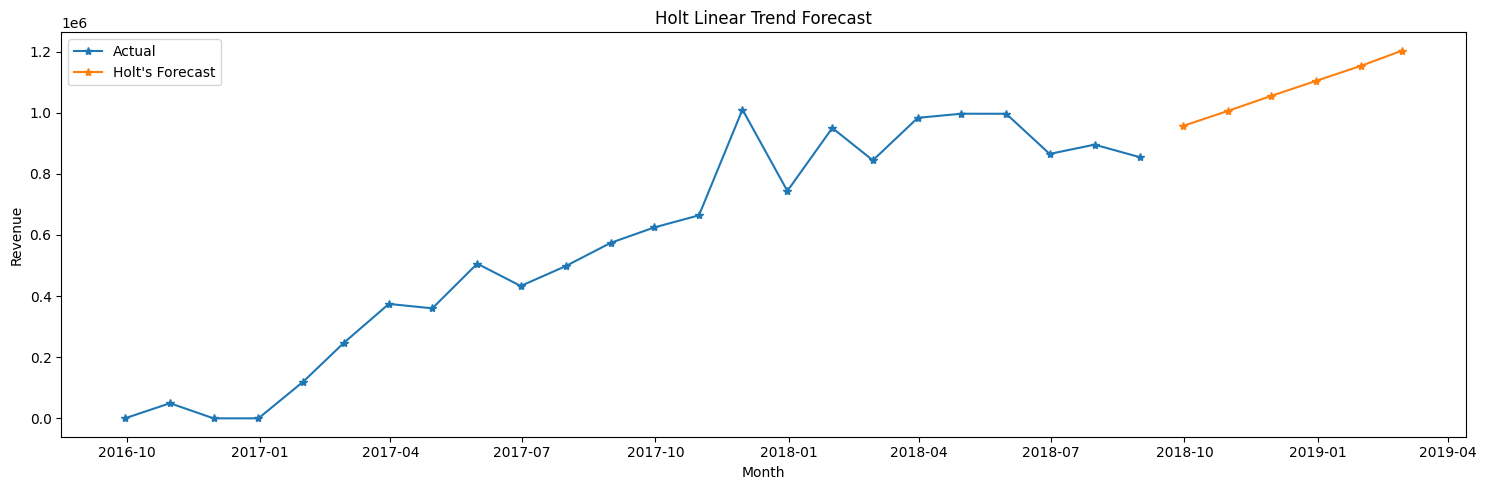

In [31]:
#lets visualize

plt.figure(figsize = (15, 5))

plt.plot(monthly_revenue.index, monthly_revenue.revenue, label = "Actual", marker = "*")

forecast_index = forecast_index = pd.date_range(
    start=monthly_revenue.index[-1] + pd.offsets.MonthEnd(1),
    periods=6,
    freq="ME"
)

plt.plot(forecast_index, holt_forecast, label = "Holt's Forecast", marker = "*")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Holt Linear Trend Forecast")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
#lets compare them

train = monthly_revenue.iloc[:-3]
test = monthly_revenue.iloc[-3:]

In [33]:
holt_model_comp = Holt(train["revenue"]).fit(optimized = True)

In [34]:
predict = holt_model_comp.forecast(len(test))

In [35]:
round(predict,2)

,0
2018-06-30,1083553.95
2018-07-31,1132794.25
2018-08-31,1182034.55


In [36]:
test.revenue

,revenue
order_purchase_timestamp,
2018-06-30,865124.31
2018-07-31,895507.22
2018-08-31,854686.33


In [37]:
#lets find the error

mae = round(((test["revenue"] - predict).abs()).mean(),2)

In [38]:
rmse = round(np.sqrt(((test["revenue"] - predict) ** 2).mean()),2)

In [39]:
mape = round((((test["revenue"] - predict).abs()/test["revenue"]).mean()) * 100,2)

In [40]:
print(f"MAE : {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}%")

MAE : 261021.63
RMSE: 265313.34
MAPE: 30.02%


#Stationarity

In [41]:
#differencing

monthly_revenue["difference"] = monthly_revenue["revenue"].diff()

In [42]:
monthly_revenue

,revenue,MA3,MA6,MA12,difference
order_purchase_timestamp,,,,,
2016-09-30,267.36,267.360000,NaN,NaN,NaN
2016-10-31,49507.66,24887.510000,NaN,NaN,49240.30
2016-11-30,0.00,16591.673333,NaN,NaN,-49507.66
2016-12-31,10.90,16506.186667,NaN,NaN,10.90
2017-01-31,120312.87,40107.923333,NaN,NaN,120301.97
2017-02-28,247303.02,122542.263333,69566.968333,NaN,126990.15
2017-03-31,374344.30,247320.063333,131913.125000,NaN,127041.28
2017-04-30,359927.23,327191.516667,183649.720000,NaN,-14417.07
2017-05-31,506071.14,413447.556667,267994.910000,NaN,146143.91


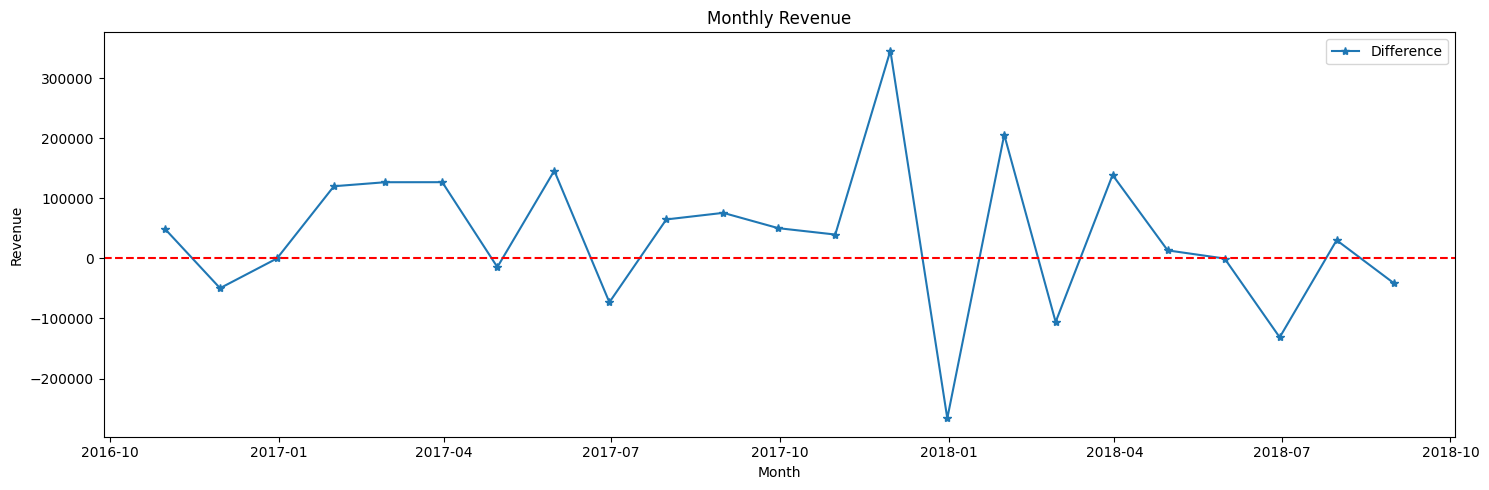

In [43]:
#lets plot differences

plt.figure(figsize = (15, 5))

plt.plot(monthly_revenue.index, monthly_revenue.difference, label = "Difference", marker = "*")

plt.axhline(y = 0, color = "red", linestyle = "--")

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue")
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
#lets do adf testing to find out the whether the data is stationary or not

from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_revenue["revenue"])

In [45]:
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.480131895562331
p-value: 0.5433159151749883


In [46]:
result_revenue = adfuller(monthly_revenue["difference"].dropna())

print("ADF Statistic:", result_revenue[0])
print("p-value:", result_revenue[1])

ADF Statistic: -8.175764309061643
p-value: 8.385731214439533e-13


#ARIMA

In [47]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

<Figure size 1500x500 with 0 Axes>

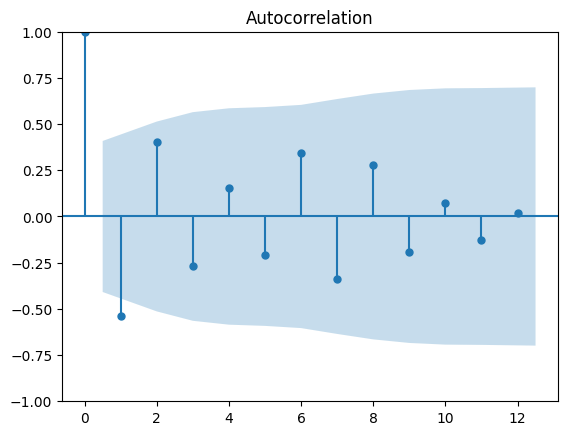

In [48]:
#lets plot them
plt.figure(figsize = (15,5))

plot_acf(monthly_revenue["difference"].dropna(), lags = 12)
plt.show()

<Figure size 1500x500 with 0 Axes>

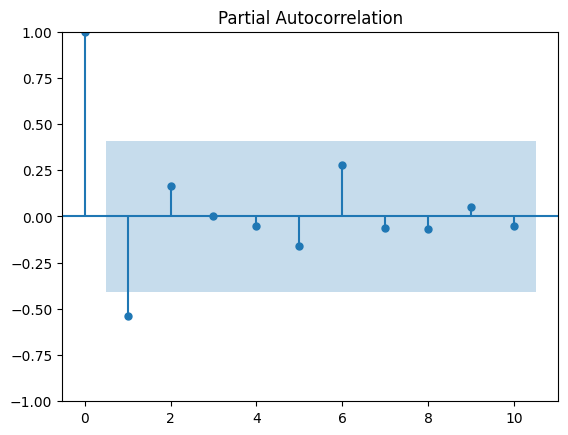

In [49]:
plt.figure(figsize=(15,5))

plot_pacf(
    monthly_revenue["difference"].dropna(),
    lags=10,
    method="ywm"
)

plt.show()

In [50]:
#lets fit the model

from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train["revenue"], order = (1,1,1))

arima_fit = arima_model.fit()

In [51]:
arima_forecast = arima_fit.forecast(len(test))

print(arima_forecast)

2018-06-30    984466.808439
2018-07-31    993572.386002
2018-08-31    986692.257678
Freq: ME, Name: predicted_mean, dtype: float64


In [52]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, mean_absolute_percentage_error)

mae = mean_absolute_error(test["revenue"], arima_forecast)

mse_value = mean_squared_error(test["revenue"], arima_forecast) # Renamed variable

rmse = np.sqrt(mse_value) # Using the renamed variable

mean_absolute_percentage_error = mean_absolute_percentage_error(test["revenue"], arima_forecast)

print(f"MAE : {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mean_absolute_percentage_error}%")

MAE : 116471.1973732245
RMSE: 117310.09285785853
MAPE: 0.13396863283988125%


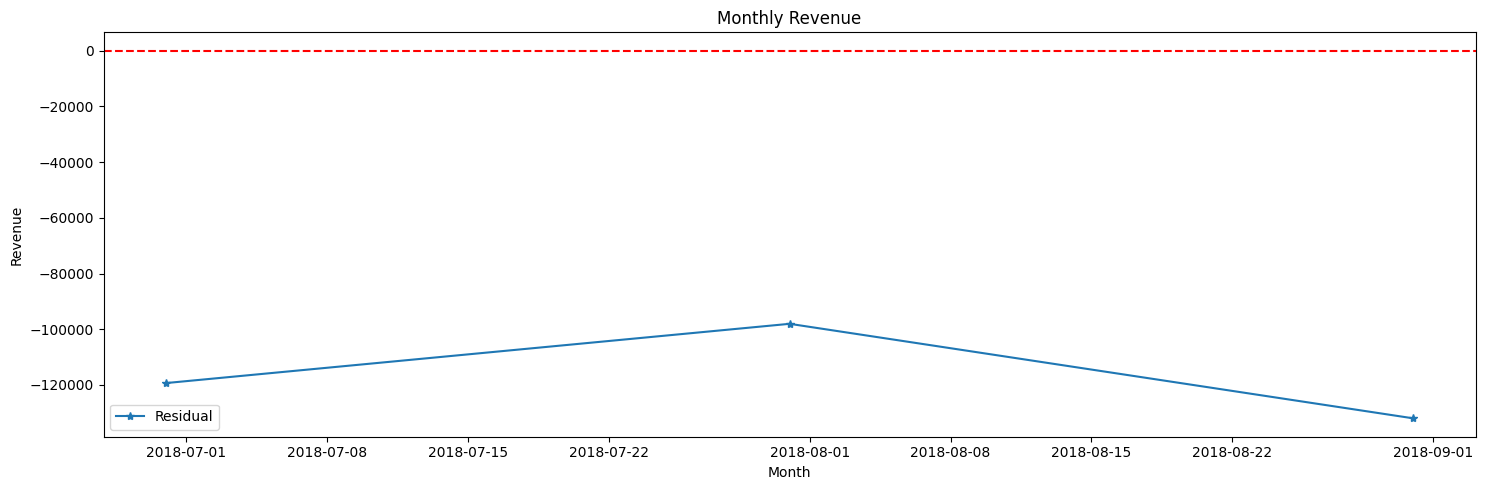

In [53]:
#residual diagnostics
#residual should be random not showing any pattern

residual = test["revenue"] - arima_forecast

plt.figure(figsize = (15,5))

plt.plot(residual, label = "Residual", marker = "*")

plt.axhline(y = 0, color = "red", linestyle = "--")

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue")
plt.legend()
plt.tight_layout()
plt.show()


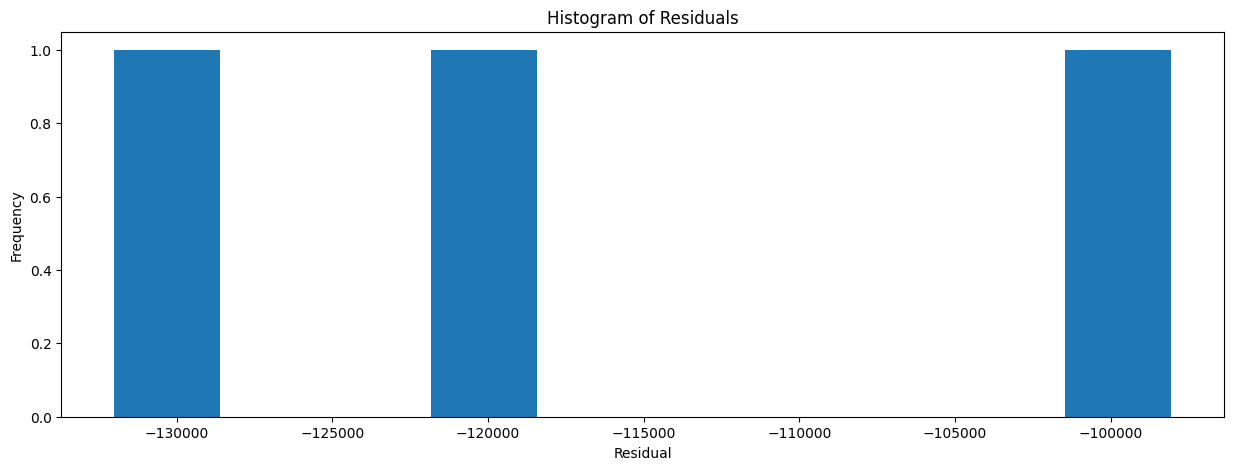

In [54]:
plt.figure(figsize = (15,5))

plt.hist(residual, bins = 10)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()


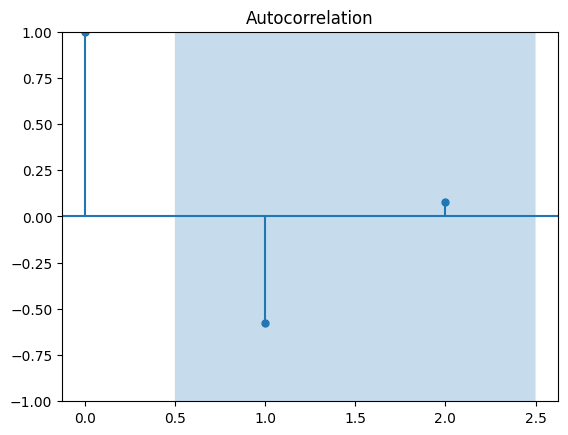

In [55]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residual, lags = 2)

plt.show()

In [56]:
#model selection

#aic - akaike information criterion : Does this model explain the data well without becoming unnecessarily complex?

#bic - bayesian information criterion, bic penalize the complexity even more

candidate_models = [(0,1,0),(0,1,1),(1,1,0),(1,1,1),(2,1,1),(1,1,2),(2,1,2)]

result = []

In [57]:
import traceback

for order in candidate_models:
  try:
    model = ARIMA(train["revenue"], order = order)
    fit = model.fit()
    forecast = fit.forecast(len(test))

    mae = mean_absolute_error(test["revenue"], forecast)
    rmse = np.sqrt(mean_squared_error(test["revenue"], forecast)) # Explicitly calling the function
    mape = np.mean(np.abs((test["revenue"] - forecast)/test["revenue"])) * 100

    result.append({"Model" : f"ARIMA model{order}", "MAE" : mae, "RMSE" : rmse, "MAPE" : mape, "AIC" : fit.aic, "BIC" : fit.bic})
  except Exception as e:
    print(f"Error with order {order}:")
    print(traceback.format_exc())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


In [58]:
result_df = pd.DataFrame(result)

In [59]:
result_df["RANK_MAPE"] = result_df["MAPE"].rank()
result_df["RANK_AIC"] = result_df["AIC"].rank()
result_df["RANK_RMSE"] = result_df["RMSE"].rank()

In [60]:
result_df["overall_score"] = result_df["RANK_MAPE"] + result_df["RANK_AIC"] + result_df["RANK_RMSE"]

In [61]:
result_df.sort_values(by = "overall_score")


,Model,MAE,RMSE,MAPE,AIC,BIC,RANK_MAPE,RANK_AIC,RANK_RMSE,overall_score
3,"ARIMA model(1, 1, 1)",116471.197373,117310.092858,13.396863,530.155352,533.142549,1.0,5.0,1.0,7.0
2,"ARIMA model(1, 1, 0)",124787.115159,125983.539405,14.358854,529.096959,531.088424,4.0,2.0,4.0,10.0
1,"ARIMA model(0, 1, 1)",122723.174149,123938.701232,14.121996,531.174431,533.165895,2.0,7.0,2.0,11.0
0,"ARIMA model(0, 1, 0)",124745.060000,125941.074253,14.354015,530.860842,531.856574,3.0,6.0,3.0,12.0
4,"ARIMA model(2, 1, 1)",228264.596147,232238.523670,26.265186,527.666906,531.649835,6.0,1.0,6.0,13.0
5,"ARIMA model(1, 1, 2)",133503.470568,135706.487173,15.371440,529.742076,533.725005,5.0,4.0,5.0,14.0
6,"ARIMA model(2, 1, 2)",229498.672478,233624.186183,26.407620,529.369841,534.348502,7.0,3.0,7.0,17.0


#SARIMA model

In [62]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [63]:
sarima_model = SARIMAX(train["revenue"], order = (1,1,1), seasonal_order = (1,1,1,12))

sarima_fit = sarima_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [64]:
sarima_forecast = sarima_fit.forecast(len(test))

In [65]:
sarima_mae = mean_absolute_error(test["revenue"], sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test["revenue"], sarima_forecast))
sarima_mape = np.mean(np.abs((test["revenue"] - sarima_forecast)/test["revenue"])) * 100

print(f"MAE : {sarima_mae}")
print(f"RMSE: {sarima_rmse}")
print(f"MAPE: {sarima_mape}%")

MAE : 138849.5470536181
RMSE: 142200.7856440194
MAPE: 15.999442513758193%


In [66]:
#understanding sarima variables PDQS

seasonal_diff = monthly_revenue["revenue"].diff(12)

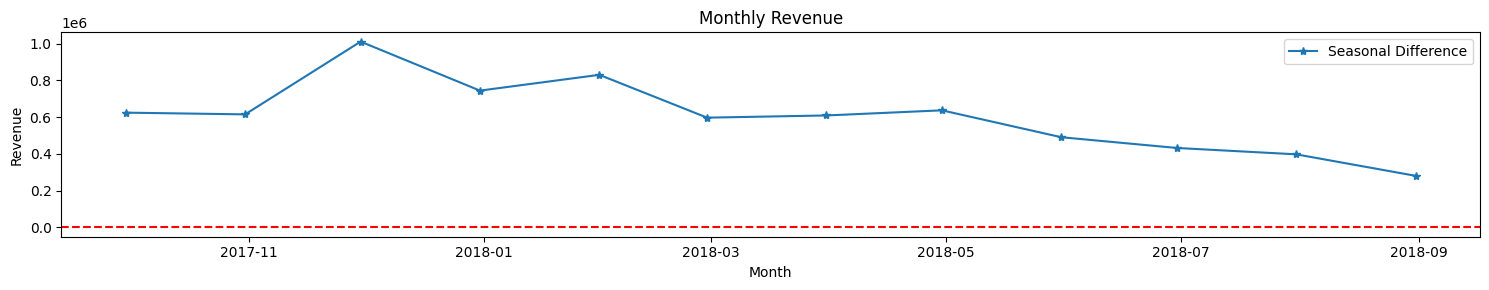

In [67]:
plt.figure(figsize = (15,3))

plt.plot(seasonal_diff, label = "Seasonal Difference", marker = "*")
plt.axhline(y = 0, color = "red", linestyle = "--")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue")
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
#seasonal difference
monthly_revenue["seasonal_difference"] = monthly_revenue["revenue"].diff(12)

result_seasonal = adfuller(monthly_revenue["seasonal_difference"].dropna())

print("ADF Statistic:", result_seasonal[0])
print("p-value:", result_seasonal[1])

ADF Statistic: 1.539447286745929
p-value: 0.9976640472284789


In [69]:
#our p value is greater so the seasonal difference is not stationary , lets do this again

diff_series = monthly_revenue["revenue"].diff().dropna()

second_diff = diff_series.diff(12).dropna()

result_diff_series = adfuller(second_diff)

print("ADF Statistic:", result_diff_series[0])
print("p-value:", result_diff_series[1])

ADF Statistic: -5.56701102271918
p-value: 1.496801063571191e-06


In [70]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

diff_series = monthly_revenue["revenue"].diff().dropna()

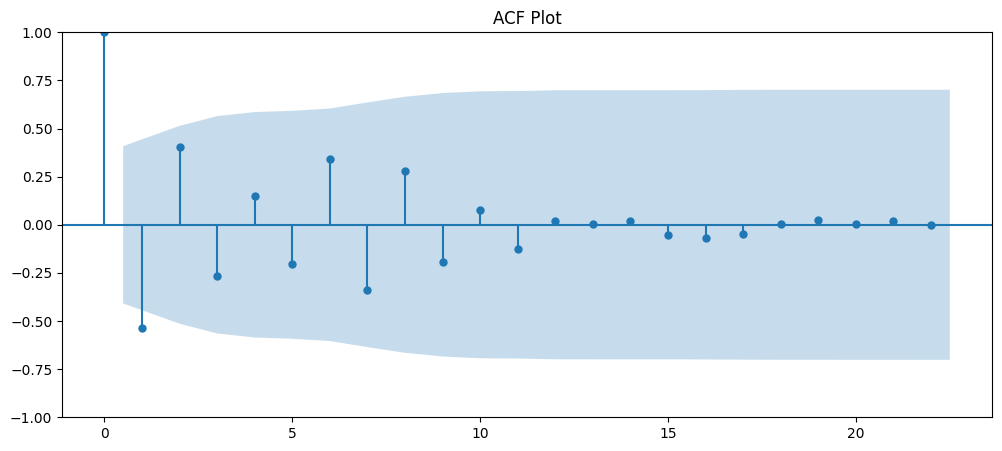

In [71]:
fig, axes = plt.subplots(figsize = (12, 5))

plot_acf(diff_series, lags = 22, ax = axes)

plt.title("ACF Plot")
plt.show()

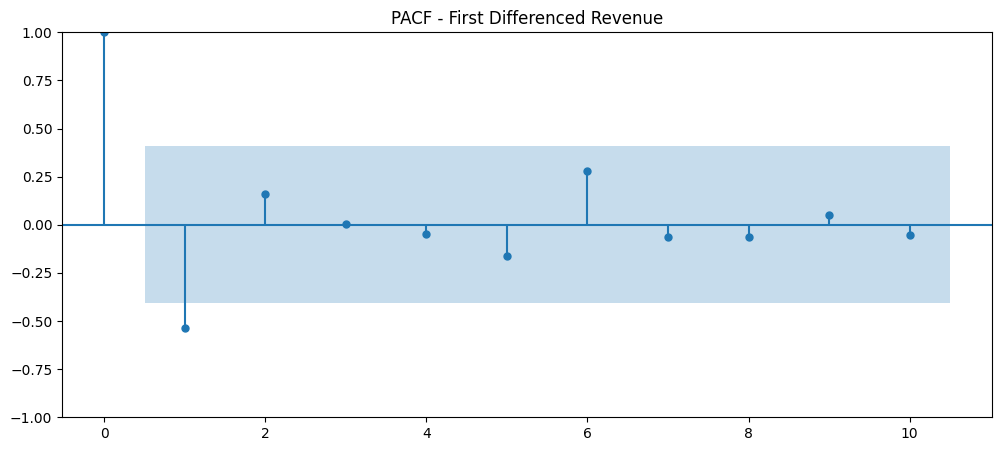

In [72]:
fig, ax = plt.subplots(figsize=(12,5))

plot_pacf(
    diff_series,
    lags=10,
    method="ywm",
    ax=ax
)

plt.title("PACF - First Differenced Revenue")
plt.show()

In [73]:
#auto ARIMA

!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.0 MB/s eta 0:00:00


In [74]:
import pmdarima as pm

In [75]:
auto_model = pm.auto_arima(train["revenue"], seasonal = False, stepwise = True, suppress_warnings = True, error_action = "ignore")

In [76]:
print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   21
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -257.607
Date:                Wed, 12 Aug 2026   AIC                            521.213
Time:                        14:37:51   BIC                            524.201
Sample:                    09-30-2016   HQIC                           521.797
                         - 05-31-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   8.384e+04   2.66e+04      3.150      0.002    3.17e+04    1.36e+05
ar.L1         -0.6483      0.206     -3.140      0.002      -1.053      -0.244
sigma2      9.424e+09      0.216   4.36e+10      0.0

In [77]:
auto_forecast = auto_model.predict(n_periods = len(test))

In [78]:
mae_auto = mean_absolute_error(test["revenue"], auto_forecast)
rmse_auto = np.sqrt(mean_squared_error(test["revenue"], auto_forecast))
mape_auto = np.mean(np.abs((test["revenue"] - auto_forecast)/test["revenue"])) * 100

print(f"MAE : {mae_auto}")
print(f"RMSE: {rmse_auto}")
print(f"MAPE: {mape_auto}")

MAE : 249872.82008768676
RMSE: 254737.7225271771
MAPE: 28.753200196792868


In [79]:
print("Selected order:", auto_model.order)
print("AIC:", auto_model.aic())

Selected order: (1, 1, 0)
AIC: 521.2134847703703


#Walk Forward Validation

In [80]:
monthly_series = monthly_revenue["revenue"]

In [81]:
monthly_series

,revenue
order_purchase_timestamp,
2016-09-30,267.36
2016-10-31,49507.66
2016-11-30,0.00
2016-12-31,10.90
2017-01-31,120312.87
2017-02-28,247303.02
2017-03-31,374344.30
2017-04-30,359927.23
2017-05-31,506071.14


In [82]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [83]:
actuals = []
predictions = []

initial_train_size = 12

for i in range(initial_train_size, len(monthly_series)):
  train_data = monthly_series.iloc[:i]
  test_data = monthly_series.iloc[i]

  # Fit ARIMA model
  model = ARIMA(train_data, order = (1,1,1)) # Using the best order found previously
  model_fit = model.fit()

  # Make one-step-ahead forecast
  forecast = model_fit.forecast(steps=1)[0] # Get the first (and only) forecast value

  actuals.append(test_data)
  predictions.append(forecast)

# Calculate evaluation metrics
mae_wf = mean_absolute_error(actuals, predictions)
rmse_wf = np.sqrt(mean_squared_error(actuals, predictions))
mape_wf = np.mean(np.abs((np.array(actuals) - np.array(predictions)) / np.array(actuals))) * 100

print(f"Walk-Forward Validation MAE: {mae_wf:.2f}")
print(f"Walk-Forward Validation RMSE: {rmse_wf:.2f}")
print(f"Walk-Forward Validation MAPE: {mape_wf:.2f}%")

/tmp/ipykernel_893/3027047027.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  forecast = model_fit.forecast(steps=1)[0] # Get the first (and only) forecast value
/tmp/ipykernel_893/3027047027.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  forecast = model_fit.forecast(steps=1)[0] # Get the first (and only) forecast value
/tmp/ipykernel_893/3027047027.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  forecast = model_fi

Walk-Forward Validation MAE: 95959.97
Walk-Forward Validation RMSE: 149366.32
Walk-Forward Validation MAPE: 10.98%


/tmp/ipykernel_893/3027047027.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  forecast = model_fit.forecast(steps=1)[0] # Get the first (and only) forecast value
/tmp/ipykernel_893/3027047027.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  forecast = model_fit.forecast(steps=1)[0] # Get the first (and only) forecast value
/tmp/ipykernel_893/3027047027.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  forecast = model_fi

In [84]:
walk_forward_results = pd.DataFrame({
    "Actual" : actuals,
    "Forecast" : predictions
})

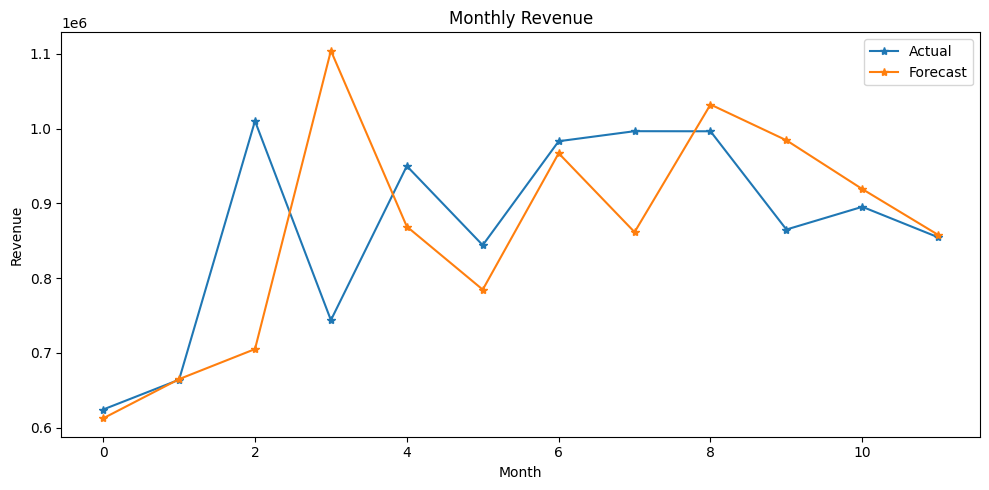

In [85]:
plt.figure(figsize = (10, 5))

plt.plot(walk_forward_results.index, walk_forward_results.Actual, label = "Actual", marker = "*")
plt.plot(walk_forward_results.index, walk_forward_results.Forecast, label = "Forecast", marker = "*")

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue")
plt.legend()
plt.tight_layout()
plt.show()

In [86]:
auto_actuals = []
auto_predictions = []
selected_orders = []

initial_train_size = 12

for i in range(initial_train_size, len(monthly_series)):
  train_data = monthly_series.iloc[:i]
  test_data = monthly_series.iloc[i]

  auto_model = pm.auto_arima(train_data, seasonal = False, stepwise = True, suppress_warnings = True, error_action = "ignore")

  auto_forecast = auto_model.predict(n_periods = 1)[0]

  auto_actuals.append(test_data)
  auto_predictions.append(auto_forecast)
  selected_orders.append(auto_model.order)

/tmp/ipykernel_893/1253560013.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  auto_forecast = auto_model.predict(n_periods = 1)[0]
/tmp/ipykernel_893/1253560013.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  auto_forecast = auto_model.predict(n_periods = 1)[0]
/tmp/ipykernel_893/1253560013.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  auto_forecast = auto_model.predict(n_periods = 1)[0]
/tmp/ipykernel_893/125356001

In [87]:
auto_mae = mean_absolute_error(auto_actuals, auto_predictions)
auto_rmse = np.sqrt(mean_squared_error(auto_actuals, auto_predictions))
auto_mape = np.mean(np.abs((np.array(auto_actuals) - np.array(auto_predictions)) / np.array(auto_actuals))) * 100

print(f"Auto ARIMA MAE: {auto_mae:.2f}")
print(f"Auto ARIMA RMSE: {auto_rmse:.2f}")
print(f"Auto ARIMA MAPE: {auto_mape:.2f}%")
print(f"Selected Orders: {selected_orders}")

Auto ARIMA MAE: 113560.65
Auto ARIMA RMSE: 156300.67
Auto ARIMA MAPE: 13.04%
Selected Orders: [(0, 1, 0), (0, 1, 0), (0, 1, 0), (0, 1, 0), (1, 1, 0), (1, 1, 0), (1, 1, 0), (1, 1, 0), (1, 1, 0), (1, 1, 0), (1, 1, 0), (1, 1, 0)]


In [88]:
auto_forward_data_frame = pd.DataFrame({"Actual" : auto_actuals, "Prediction" : auto_predictions})

In [89]:
auto_forward_data_frame

,Actual,Prediction
0,624401.69,6.261266e+05
1,664219.43,6.764129e+05
2,1010271.37,7.152927e+05
3,743914.17,1.082415e+06
4,950030.36,1.055820e+06
5,844178.71,9.099847e+05
6,983213.44,1.005385e+06
7,996647.75,9.788260e+05
8,996517.68,1.076377e+06
9,865124.31,1.080438e+06


In [90]:
holt_actuals = []
holt_predictions = []

initial_train_size = 12

for i in range(initial_train_size, len(monthly_series)):

    # Historical data available at this point
    train_data = monthly_series.iloc[:i]

    # The next month we are trying to predict
    test_value = monthly_series.iloc[i]

    # Fit Holt model
    holt_model = Holt(
        train_data,
        initialization_method="estimated"
    )

    holt_fit = holt_model.fit(
        optimized=True
    )

    # Forecast one month ahead
    forecast = holt_fit.forecast(
        steps=1
    )

    holt_actuals.append(test_value)
    holt_predictions.append(forecast.iloc[0])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [91]:
holt_mae = mean_absolute_error(
    holt_actuals,
    holt_predictions
)

holt_rmse = np.sqrt(
    mean_squared_error(
        holt_actuals,
        holt_predictions
    )
)

holt_mape = np.mean(
    np.abs(
        (
            np.array(holt_actuals)
            -
            np.array(holt_predictions)
        )
        /
        np.array(holt_actuals)
    )
) * 100

print("Holt Walk-Forward MAE:", holt_mae)
print("Holt Walk-Forward RMSE:", holt_rmse)
print("Holt Walk-Forward MAPE:", holt_mape)

Holt Walk-Forward MAE: 127600.40604568044
Holt Walk-Forward RMSE: 158695.0741497887
Holt Walk-Forward MAPE: 14.424707211756814


In [97]:
holt_walk_forward_results = pd.DataFrame({
    "Actual" : holt_actuals,
    "Forecast" : holt_predictions
})

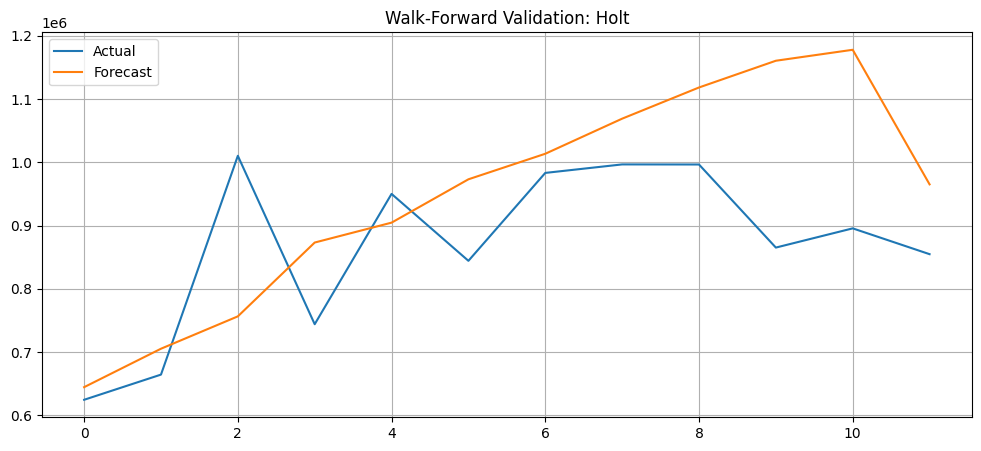

In [98]:
plt.figure(figsize=(12,5))

plt.plot(
    holt_walk_forward_results["Actual"],
    label="Actual"
)

plt.plot(
    holt_walk_forward_results["Forecast"],
    label="Forecast"
)

plt.title(
    "Walk-Forward Validation: Holt"
)

plt.legend()
plt.grid(True)

plt.show()

#Residual diagnostics

In [99]:
residuals = arima_fit.resid

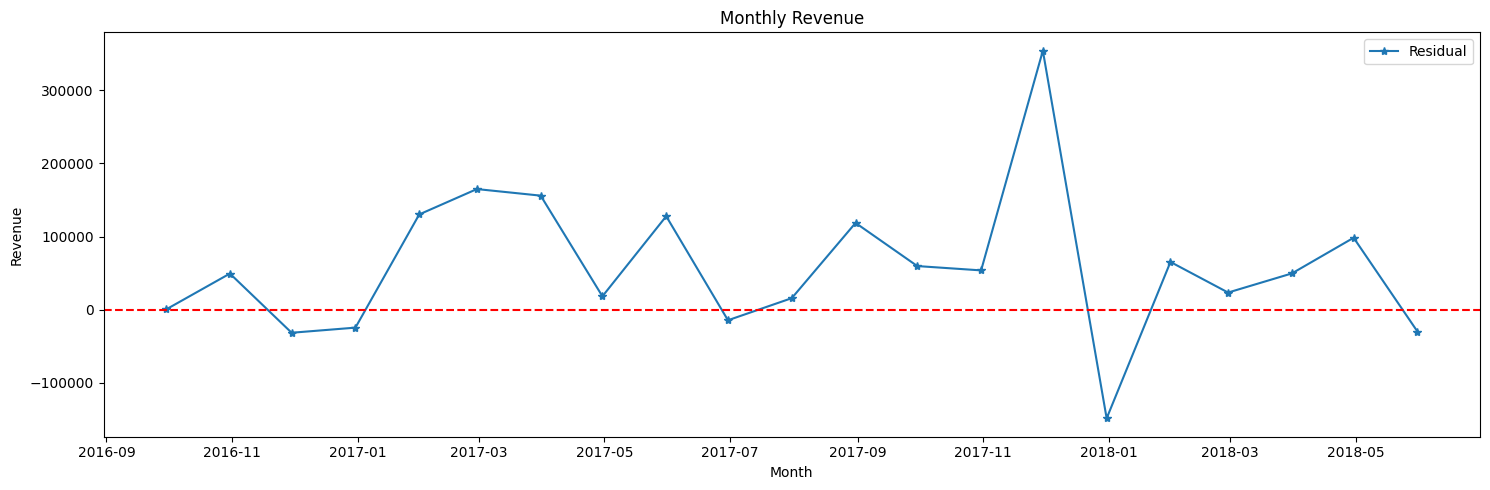

In [101]:
plt.figure(figsize = (15,5))

plt.plot(residuals, label = "Residual", marker = "*")

plt.axhline(y = 0, color = "red", linestyle = "--")

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue")
plt.legend()
plt.tight_layout()
plt.show()


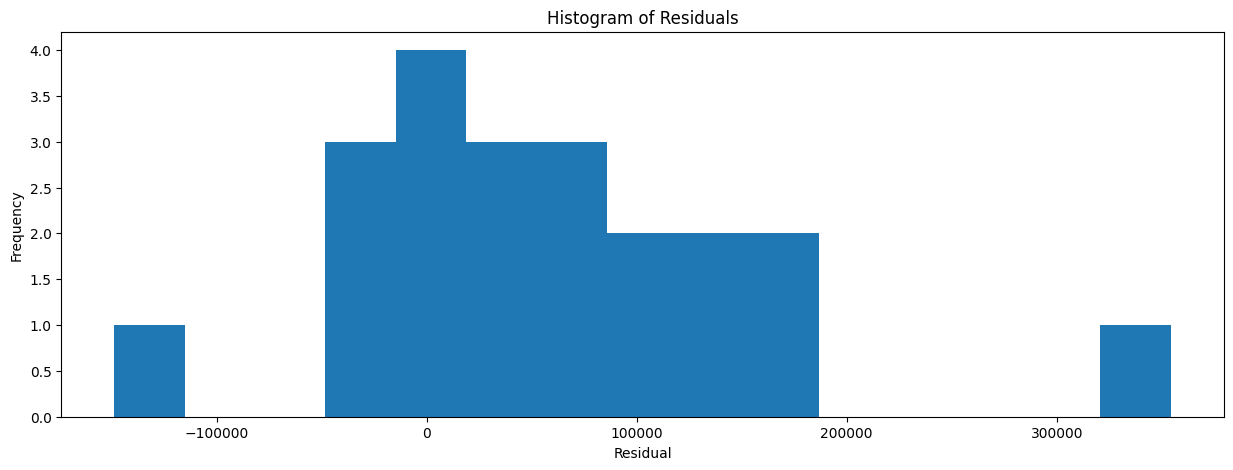

In [106]:
plt.figure(figsize = (15,5))

plt.hist(residuals, bins = 15)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

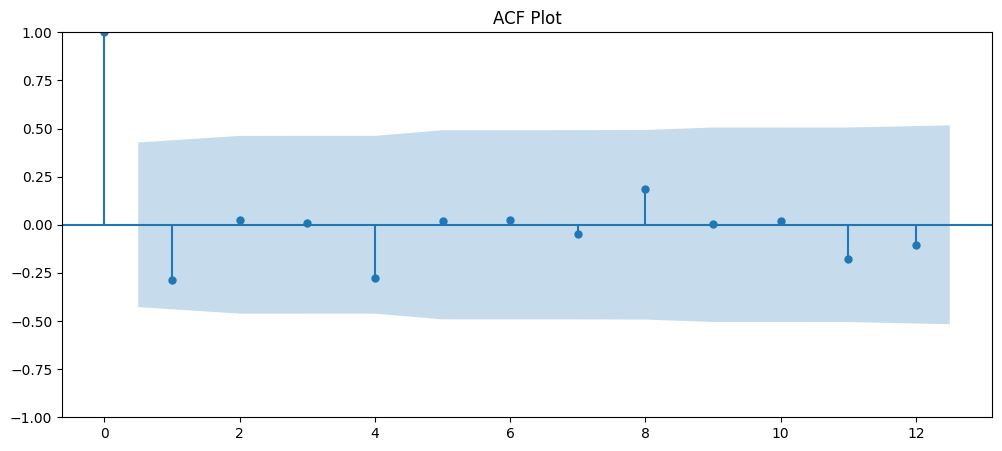

In [103]:
fig, axes = plt.subplots(figsize = (12, 5))

plot_acf(residuals, lags = 12, ax = axes)

plt.title("ACF Plot")
plt.show()

In [105]:
#The Ljung–Box Test
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    residuals,
    lags=[6, 12],
    return_df=True
)

print(ljung_box)

     lb_stat  lb_pvalue
6   4.214560   0.647666
12  7.692155   0.808701
